# 🚀 SciFi Forge — V1 LSTM Baseline

**Character-level LSTM trained on 149M characters of science fiction text.**

This notebook orchestrates the V1 baseline by calling the production `.py` modules directly.
All logic lives in `v1_baseline/` — this notebook is purely for recording, visualisation, and portfolio presentation.

| File | Responsibility |
|---|---|
| `v1_baseline/lstm_model.py` | `CharLSTM` model definition |
| `v1_baseline/train.py` | Training loop, checkpointing, early stopping |
| `v1_baseline/generate.py` | Text generation from saved weights |
| `v1_baseline/evaluate.py` | Perplexity, BLEU-2, speed → `eval_results_v1.json` |

## 0. Setup

In [5]:
import os, sys
os.environ["TF_CPP_MIN_LOG_LEVEL"]  = "3"
os.environ["TF_ENABLE_ONEDNN_OPTS"] = "0"

# ── Add project root to path so v1_baseline imports resolve ──────────────
from pathlib import Path
ROOT = Path("../").resolve()          # adjust if notebook is not in v1_baseline/
sys.path.insert(0, str(ROOT))
sys.path.insert(0, str(ROOT / "v1_baseline"))

import torch
print(f"Python : {sys.version.split()[0]}")
print(f"PyTorch: {torch.__version__}")
print(f"CUDA   : {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU    : {torch.cuda.get_device_name(0)}")
    print(f"VRAM   : {torch.cuda.get_device_properties(0).total_memory/1e9:.1f} GB")

# Verify corpus
CORPUS = ROOT / "data/raw/internet_archive_scifi_v3.txt"
assert CORPUS.exists(), f"Corpus not found: {CORPUS}"
print(f"\nCorpus : {CORPUS.stat().st_size/1e6:.0f} MB  ✅")

Python : 3.12.3
PyTorch: 2.10.0+cu130
CUDA   : True
GPU    : NVIDIA GeForce RTX 4060 Laptop GPU
VRAM   : 8.2 GB

Corpus : 149 MB  ✅


## 1. Train

Calls `v1_baseline/train.py` directly.  
Checkpoints saved to `checkpoints/lstm_checkpoints/checkpt_N.pt`  
Best checkpoint saved as `checkpt_best.pt` automatically.  
Early stopping patience = 2 epochs (matches original notebook).

In [3]:
# Runs the full training loop
# Output is streamed live to this cell
# To resume a crashed run: change resume=True

from v1_baseline.train import train

train(resume=True)

Device: cuda
Characters: 149,294,026 | Unique: 75
Resumed from mid-epoch checkpoint (epoch 3, batch 800000)
  Epoch 3 | batch 800500/1166358 | loss 25.9117
  Epoch 3 | batch 801000/1166358 | loss 28.9585
  Epoch 3 | batch 801500/1166358 | loss 28.5896
  Epoch 3 | batch 802000/1166358 | loss 29.9132
  Epoch 3 | batch 802500/1166358 | loss 27.2842
  Epoch 3 | batch 803000/1166358 | loss 27.2419
  Epoch 3 | batch 803500/1166358 | loss 28.1199
  Epoch 3 | batch 804000/1166358 | loss 27.3024
  Epoch 3 | batch 804500/1166358 | loss 27.4427
  Epoch 3 | batch 805000/1166358 | loss 28.4725
  Epoch 3 | batch 805500/1166358 | loss 29.9600
  Epoch 3 | batch 806000/1166358 | loss 27.1718
  Epoch 3 | batch 806500/1166358 | loss 28.4132
  Epoch 3 | batch 807000/1166358 | loss 29.8892
  Epoch 3 | batch 807500/1166358 | loss 27.4389
  Epoch 3 | batch 808000/1166358 | loss 29.3576
  Epoch 3 | batch 808500/1166358 | loss 28.2280
  Epoch 3 | batch 809000/1166358 | loss 29.0117
  Epoch 3 | batch 809500/116

## 2. Plot Training Loss

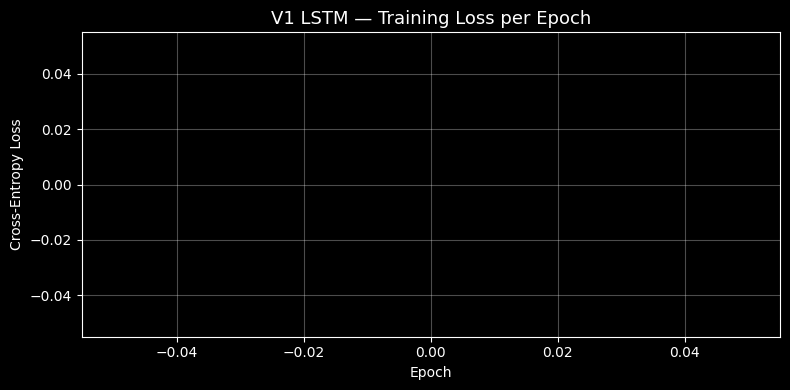

In [7]:
import json
import matplotlib.pyplot as plt

CKPT_DIR = ROOT / "checkpoints/lstm_checkpoints"

# Collect loss from each saved per-epoch checkpoint
epochs, losses = [], []
for ckpt in sorted(CKPT_DIR.glob("checkpt_[0-9]*.pt")):
    state = torch.load(ckpt, map_location="cpu", weights_only=False)
    epochs.append(state["epoch"])
    losses.append(state["loss"])

plt.figure(figsize=(8, 4))
plt.plot(epochs, losses, marker="o", color="#f5a623", linewidth=2)
plt.title("V1 LSTM — Training Loss per Epoch", fontsize=13)
plt.xlabel("Epoch");  plt.ylabel("Cross-Entropy Loss")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(ROOT / "mlflow_runs/v1_loss_curve.png", dpi=120)
plt.show()

for e, l in zip(epochs, losses):
    print(f"  Epoch {e:02d}: {l:.4f}")
# print(f"\nBest: {min(losses):.4f} at epoch {epochs[losses.index(min(losses))]}")

## 3. Generate Text

In [8]:
from v1_baseline.generate import load_inference_model, generate_text

model, chartoindex, indextochar = load_inference_model()

Characters: 149,294,026 | Unique: 75
Loaded checkpoint: checkpoints/lstm_checkpoints/checkpt_best.pt


In [9]:
# ── Short sample ──────────────────────────────────────────────────────────
print(generate_text(model, chartoindex, indextochar,
                    "The spaceship landed on",
                    num=100, temperature=0.4))

The spaceship landed oner could have been the only one of the past the ships are more than a second and
had the same as a s


In [10]:
# ── Paragraph sample ──────────────────────────────────────────────────────
print(generate_text(model, chartoindex, indextochar,
                    "The alien vessel emerged from hyperspace and",
                    num=1000, temperature=0.5))

The alien vessel emerged from hyperspace andith shut a great deal of reports of the camp that had to be found in the lab on
the ship. But the same reason in the country was a rough space and looked at the
city was a small part of the cave in the courtyard and the cartographer had the
advanced from the training more steps to his back and sighed. "We have to be as
soon as you don't know what it is a basic system for any more like this that we
can see or anything at all to rest for the stars will be a step for the paper
and seventy-five or testing and the first time the day before he had seen the
way to the sheet of her station from the cannon was a short beams of the
conditions of the world came out of the streets of the control companion of the
spin of the house and his face was still away from the first gray cheeks. The
Sunday and was still wanted to recognize the couch. Not a hand before the first
of the sun was a very large ship to the beach and closed and said, "I had to be
a long t

In [11]:
# ── Try your own seed ─────────────────────────────────────────────────────
SEED = "Captain Chen stared at the dying star and"   # ← change this
print(generate_text(model, chartoindex, indextochar, SEED, num=500, temperature=0.5))

Captain Chen stared at the dying star andress. It came to a star of the screen and over. "I'm going to ask you to do a
contract the other answer to the death of Galaxy Publishing Editor Earth is
supposed to be a little story that we went into the corner of the room in the
direction of the moon. "Maybe you've built the best of my own lines were the
word seemed to be completely simple and was sure that the man was within the
wall of the two of them looked at him with a steel thought of the paper between
the roots of the computer space sh


## 4. Evaluate — Benchmark Metrics

In [12]:
# Runs full evaluation and saves eval_results_v1.json
# Takes ~5-10 min

from v1_baseline.evaluate import run_evaluation

results = run_evaluation()

Loading model from checkpoints/lstm_checkpoints/checkpt_best.pt...
Characters: 149,294,026 | Unique: 75
Loaded checkpoint: checkpoints/lstm_checkpoints/checkpt_best.pt
Characters: 149,294,026 | Unique: 75
Computing perplexity...
Computing inference speed...
Computing BLEU-2...

── V1 Benchmark Results ──────────────────────────────────
  model: V1_LSTM_PyTorch
  checkpoint: checkpoints/lstm_checkpoints/checkpt_best.pt
  char_perplexity: 2.9674
  bleu2: 0.6812
  inference_chars_per_sec: 4628.68
  avg_sentence_length_chars: 165.33

Saved → eval_results_v1.json


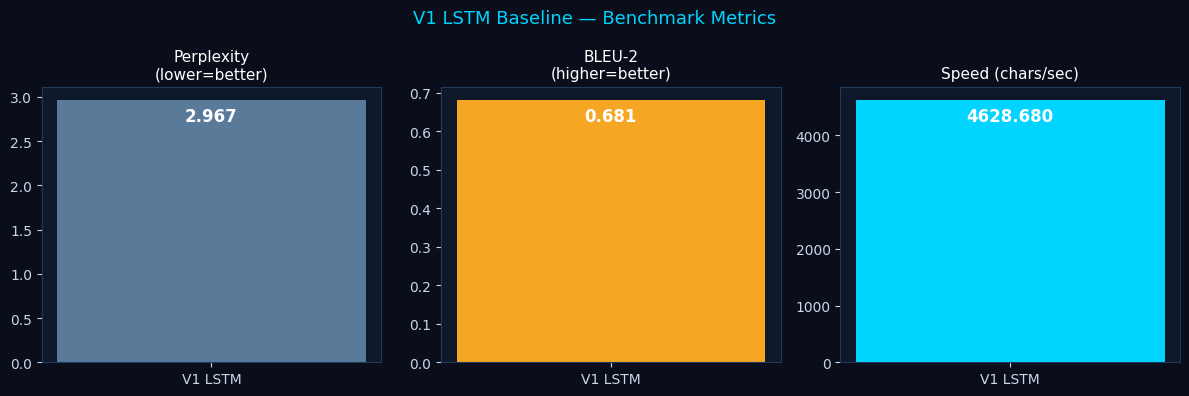

Saved: mlflow_runs/v1_metrics.png


In [13]:
# ── Display results as a summary chart ───────────────────────────────────
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(12, 4))
metrics = [
    ("Perplexity\n(lower=better)",  results["char_perplexity"],          "#5a7a9a"),
    ("BLEU-2\n(higher=better)",     results["bleu2"],                    "#f5a623"),
    ("Speed (chars/sec)",            results["inference_chars_per_sec"],  "#00d4ff"),
]
for ax, (label, val, col) in zip(axes, metrics):
    ax.bar(["V1 LSTM"], [val], color=col, width=0.4)
    ax.set_title(label, fontsize=11)
    ax.text(0, val * 0.92, f"{val:.3f}", ha="center",
            fontsize=12, color="white", fontweight="bold")
    ax.set_facecolor("#0f1829")
    ax.tick_params(colors="#c8d8e8")
    for spine in ax.spines.values():
        spine.set_edgecolor("#1e3a5f")

fig.patch.set_facecolor("#090e1a")
plt.suptitle("V1 LSTM Baseline — Benchmark Metrics", color="#00d4ff", fontsize=13)
plt.tight_layout()
plt.savefig(ROOT / "mlflow_runs/v1_metrics.png", dpi=120,
            facecolor=fig.get_facecolor())
plt.show()
print("Saved: mlflow_runs/v1_metrics.png")

## ✅ V1 Complete

| Item | Value |
|---|---|
| Architecture | `Embedding(256) → LSTM(1024) → Linear(75)` |
| Corpus | 149M chars, 75 unique characters |
| Best checkpoint | `checkpoints/lstm_checkpoints/checkpt_best.pt` |
| Benchmark results | `v1_baseline/eval_results_v1.json` |

**Next notebook:** `V2_Finetuning.ipynb` — QLoRA fine-tune Qwen2.5-1.5B.